In [1]:
import numpy as np
import matplotlib.pyplot as plt

(-0.001, 15.1)

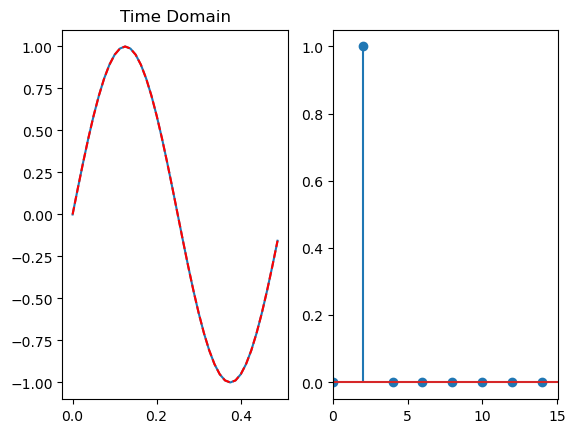

In [ ]:
N = 40
fs = 80

n = np.arange(N)
t = n / fs

# hann_window = np.sin((n * np.pi) / N) ** 2
hann_window = np.sin(2 * np.pi * 2 * t)
hann_fCoeffs = np.fft.fft(hann_window)
hann_recon = np.fft.ifft(hann_fCoeffs)

hz = np.fft.fftfreq(N, 1 / fs)

plt.subplot(121)
plt.plot(t, hann_window)
plt.plot(t, hann_recon, "r--")
plt.title("Time Domain")

plt.subplot(122)
plt.stem(hz, np.abs(hann_fCoeffs) / N * 2)
plt.xlim(-0.001, 15.1)

(80,) (80,)


(-0.001, 7.1)

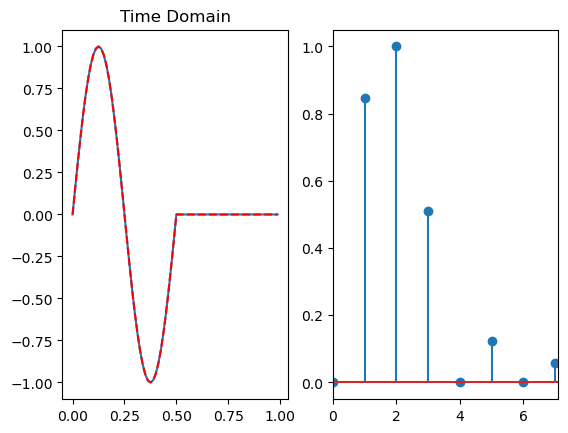

In [192]:
# FUUUU

N = 40
n_zeros = 40
fs = 80

n = np.arange(N)
t = np.arange(N + n_zeros) / fs

# hann_window = np.sin((n * np.pi) / N) ** 2
hann_window = np.sin(2 * np.pi * 2 * n / fs)
hann_window = np.concatenate([hann_window, np.zeros(n_zeros)])
hann_fCoeffs = np.fft.fft(hann_window)
hann_recon = np.fft.ifft(hann_fCoeffs)

print(t.shape, hann_window.shape)

hann_fCoeffs *= 2/N
hann_fCoeffs[0] /= 2

hz = np.fft.fftfreq(N + n_zeros, 1 / fs)

plt.subplot(121)
plt.plot(t, hann_window)
plt.plot(t, hann_recon, "r--")
plt.title("Time Domain")

plt.subplot(122)
plt.stem(hz, np.abs(hann_fCoeffs))
plt.xlim(-0.001, 7.1)

(4040,) (4000,)


(-0.001, 7.1)

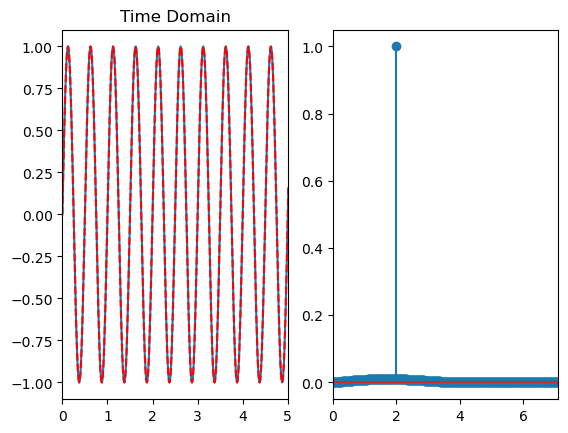

In [207]:
# FUUUU

N = 4000
n_zeros = 40
fs = 80

n = np.arange(N)
t = np.arange(N + n_zeros) / fs

# hann_window = np.sin((n * np.pi) / N) ** 2
hann_window = np.sin(2 * np.pi * 2 * n / fs)
hann_fCoeffs = np.fft.fft(hann_window, N + n_zeros)
hann_recon = np.fft.ifft(hann_fCoeffs)

print(t.shape, hann_window.shape)

hann_fCoeffs *= 2/N
hann_fCoeffs[0] /= 2

hz = np.fft.fftfreq(N + n_zeros, 1 / fs)

plt.subplot(121)
plt.plot(t[:N], hann_window)
plt.plot(t, hann_recon, "r--")
plt.title("Time Domain")
plt.xlim(0, 5)

plt.subplot(122)
plt.stem(hz, np.abs(hann_fCoeffs))
plt.xlim(-0.001, 7.1)

# Micro level precision

(0.0, 5.0)

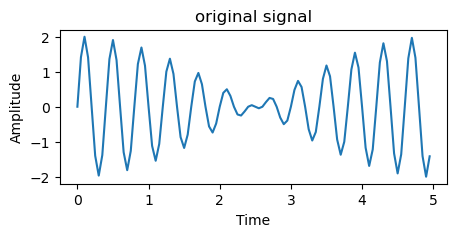

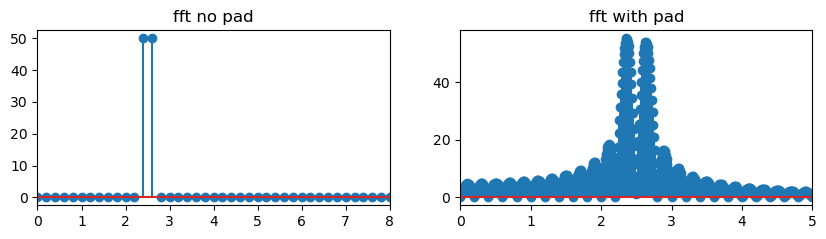

In [253]:
fs = 100 * 1/5
N = 100
t = np.arange(N) / fs
n = np.arange(N)
targetFreq = 2.4
targetFreq2 = 2.6

signal = np.sin(2 * np.pi * targetFreq * t) + np.sin(2 * np.pi * targetFreq2 * t)

# note that freq resolution: df = fs / Ntotal = 100 / 100 = 1HZ

N_pad = 2000

fft_no_pad = np.abs(np.fft.rfft(signal))
hz_no_pad = np.fft.rfftfreq(N, 1/fs)

fft_with_pad = np.abs(np.fft.rfft(signal, N_pad))
hz_with_pad = np.fft.rfftfreq(N_pad, 1/fs)

plt.figure(figsize=(5, 2))
plt.plot(t, signal)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.title("original signal")

plt.figure(figsize=(10, 5))
plt.subplot(221)
plt.stem(hz_no_pad, fft_no_pad)
plt.title("fft no pad")
plt.xlim(0, 8)

plt.subplot(222)
plt.stem(hz_with_pad, fft_with_pad)
plt.title("fft with pad")
plt.xlim(0, 5)


<StemContainer object of 3 artists>

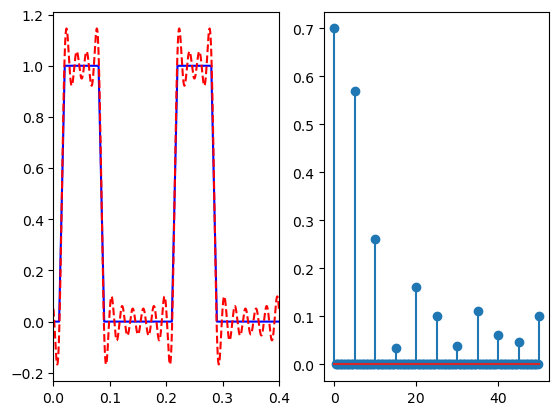

In [343]:
fs = 100
N = 300
N_pad = N * 1000

t = np.arange(N) / fs
n = np.arange(N)
t_new = np.arange(N_pad) / (fs * N_pad / N)

signal = np.sin(2 * np.pi * 5 * t) >= 0.5
fCoeffs = np.fft.rfft(signal)
hz = np.fft.rfftfreq(N, 1/fs)
recon = np.fft.irfft(fCoeffs, n=N_pad)


plt.subplot(121)
plt.plot(t, signal, 'b', label='original')
plt.plot(t_new, recon * N_pad/N, 'r--', label='recon')
plt.xlim(0, 0.4)

plt.subplot(122)
plt.stem(hz, np.abs(fCoeffs / N * 2))